# Constructing a New GPDR Example: Multidimensional x Tutorial

This notebook shows how to construct the two-dimensional simulation example using the package API. It mirrors the finalized standalone notebook `logistic_gp_density_vi_multix_thickertail_adam.ipynb`, but the GPDR model, Student-t base, inducing grid, and training loop come from the `gpdr` package.

The goal is to make the workflow reusable for new examples:

1. Prepare data `(x, y)`.
2. Define the original base model used for evaluation, here a misspecified Normal model `g_tilde`.
3. Define the heavy-tail training base `g`, here a diffuse Student-t model with the same location but scale multiplied by 3.
4. Build the GPDR model with chosen kernel hyperparameters and beta.
5. Train with Adam and iterate averaging.
6. Evaluate and draw the same figures from the package model predictions.

Important convention: the Student-t base is only used inside GPDR training. All visual comparisons below use the original Normal base `g_tilde` and the final predicted y-density `hhat`.

In [12]:
from pathlib import Path
import sys

# Make the local package importable when this notebook is run from gpdr_package/.
PACKAGE_ROOT = Path.cwd()
if not (PACKAGE_ROOT / "gpdr").exists():
    PACKAGE_ROOT = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
if str(PACKAGE_ROOT) not in sys.path:
    sys.path.insert(0, str(PACKAGE_ROOT))

import math
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm

from gpdr import build_multix_toy_model, prepare_multix_toy_data
from gpdr.training import fit_adam

torch.set_default_dtype(torch.float64)
torch.manual_seed(2)
np.random.seed(2)
device = torch.device("cpu")

## 1. Data-generating mechanism

The simulation uses two covariates, but only `x1` controls the true conditional density:

```text
x = (x1, x2),    x1, x2 iid Uniform(0, 1)
y | x ~ Normal(x1 + x1^2, 0.2 x1)
```

The package helper below reproduces the finalized notebook setup exactly: `n_total = 50_000`, data seed `3`, split seed `4`, and a 90/10 train-test split.

In [13]:
data = prepare_multix_toy_data(n_total=50_000, seed_data=3, seed_split=4, device=device)
x, y = data["x"], data["y"]
x_test, y_test = data["x_test"], data["y_test"]

print(f"train shape: x={tuple(x.shape)}, y={tuple(y.shape)}")
print(f"test shape:  x={tuple(x_test.shape)}, y={tuple(y_test.shape)}")

train shape: x=(45000, 2), y=(45000,)
test shape:  x=(5000, 2), y=(5000,)


## 2. Original base model and heavy-tail training base

For this example the original base model is a misspecified Normal regression on a one-dimensional index:

```text
s(x) = x1 + 0.1 x2
g_tilde(y | x) = Normal(b_base s(x), sigma_normal)
```

The heavy-tail training base keeps the same location but uses a diffuse Student-t distribution:

```text
g(y | x) = StudentT(df=3, loc=b_base s(x), scale=3 sigma_normal)
```

The package stores this Student-t training base in `data["base"]`. We still define `g_tilde_np` below because all figures and final evaluation compare the GPDR prediction against the original Normal base.

In [14]:
b_base = data["b_base"]
ORIGINAL_SIGMA_NORMAL = data["sigma_normal"]
DF = data["df_t"]
SCALE_T = data["scale_t"]

def base_index(x_value):
    if torch.is_tensor(x_value):
        if x_value.ndim == 1:
            x_value = x_value.reshape(1, -1)
        return x_value[:, 0] + 0.1 * x_value[:, 1]
    x_value = np.asarray(x_value)
    return x_value[..., 0] + 0.1 * x_value[..., 1]

def true_h_np(y_np, x_star):
    x_star = np.asarray(x_star)
    return norm.pdf(y_np, loc=x_star[0] + x_star[0] ** 2, scale=0.2 * x_star[0])

def true_mean_np(x1):
    return x1 + x1 ** 2

def g_tilde_np(y_np, x_star):
    mu = b_base * base_index(np.asarray(x_star))
    return norm.pdf(y_np, loc=mu, scale=ORIGINAL_SIGMA_NORMAL)

print(f"Original Normal base g_tilde: loc = {b_base:.4f} * (x1 + 0.1*x2), scale = {ORIGINAL_SIGMA_NORMAL:.4f}")
print(f"Training Student-t base g:    df = {DF:.0f}, scale = {SCALE_T:.4f}")

Original Normal base g_tilde: loc = 1.6133 * (x1 + 0.1*x2), scale = 0.1817
Training Student-t base g:    df = 3, scale = 0.5451


## 3. Build the GPDR package model

The package builder `build_multix_toy_model` fixes the same GPDR hyperparameters as the finalized standalone notebook:

```text
C = 1
m_induce = 15^2, implemented as a 6 x 6 x 6 unit tensor grid = 216 points
beta = 2200
sigma = 0.25
lx = 0.28 for both x dimensions
lz = 0.45
```

For a new example, this is the main pattern to adapt: replace the data preparation, base model, kernel hyperparameters, inducing strategy, and beta, while still using `LogisticGPMixtureDiag` and `fit_adam`.

In [15]:
torch.manual_seed(2)
np.random.seed(2)
model = build_multix_toy_model(data, C=1, m_induce=15**2, beta=2200.0, seed=2).to(device)

print(model)
print(f"inducing grid shape: {tuple(model.Vu.shape)}")
print(f"kernel sigma: {math.sqrt(float(model.kern.sigma2)):.4f}")
print(f"kernel lx: {torch.sqrt(model.kern.lx2).detach().cpu().numpy()}")
print(f"kernel lz: {math.sqrt(float(model.kern.lz2)):.4f}")

LogisticGPMixtureDiag(
  (kern): RBFSEARD()
)
inducing grid shape: (216, 3)
kernel sigma: 0.2500
kernel lx: [0.28 0.28]
kernel lz: 0.4500


## 4. Train with Adam

This reproduces the finalized notebook training setup: Adam with initial learning rate `0.5`, `6000` steps, and iterate averaging over the last `1000` steps.

Running this cell is the expensive part of the demo. On CPU it may take several minutes depending on the machine.

In [16]:
model, trace = fit_adam(
    model,
    steps=6_000,
    lr=0.5,
    average_last=1_000,
    verbose_every=500,
)

Step      1/6000 | F = 6873.100330
Step    500/6000 | F = -130698.205298
Step   1000/6000 | F = -173986.915893
Step   1500/6000 | F = -186343.807185
Step   2000/6000 | F = -189740.561180
Step   2500/6000 | F = -189839.000934
Step   3000/6000 | F = -191048.846474
Step   3500/6000 | F = -191192.734121
Step   4000/6000 | F = -191194.623477
Step   4500/6000 | F = -191190.074475
Step   5000/6000 | F = -191182.272050
Step   5500/6000 | F = -191244.113781
Step   6000/6000 | F = -191245.151910


## 5. Panel A: density comparison

This is the direct y-density comparison. The GPDR prediction comes from `model.predict_density`. The plotted base curve is the original Normal base `g_tilde`, not the Student-t training base returned by `predict_density`.

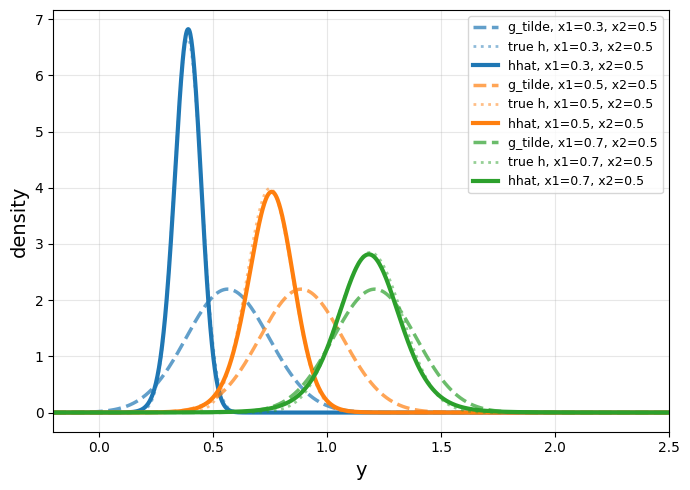

In [17]:
x_vals = np.array([[0.3, 0.5], [0.5, 0.5], [0.7, 0.5]])
colors = ["C0", "C1", "C2"]
y_min, y_max, M = -0.2, 2.5, 1200

fig_a, ax_a = plt.subplots(1, 1, figsize=(7, 5))
for x_star, col in zip(x_vals, colors):
    yg, _, hhat, _, _ = model.predict_density(x_star, y_min=y_min, y_max=y_max, M=M)
    h_true = true_h_np(yg, x_star)
    g_tilde = g_tilde_np(yg, x_star)
    label_x = f"x1={x_star[0]:.1f}, x2={x_star[1]:.1f}"
    ax_a.plot(yg, g_tilde, "--", color=col, lw=2.5, alpha=0.7, label=f"g_tilde, {label_x}")
    ax_a.plot(yg, h_true, ":", color=col, lw=2, alpha=0.5, label=f"true h, {label_x}")
    ax_a.plot(yg, hhat, "-", color=col, lw=3, label=f"hhat, {label_x}")
ax_a.set_xlabel("y", fontsize=14)
ax_a.set_ylabel("density", fontsize=14)
ax_a.legend(fontsize=9)
ax_a.grid(True, alpha=0.3)
ax_a.set_xlim(y_min, y_max)
plt.tight_layout()
plt.show()

## 6. Panel B: density ratio relative to the original base

The x-axis is `z_tilde = G_tilde(y | x)` from the original Normal base. The ratios are computed directly from the final y-density curves:

```text
predicted ratio = hhat(y | x) / g_tilde(y | x)
true ratio      = h_true(y | x) / g_tilde(y | x)
```

No Student-t quantity is used in this visualization.

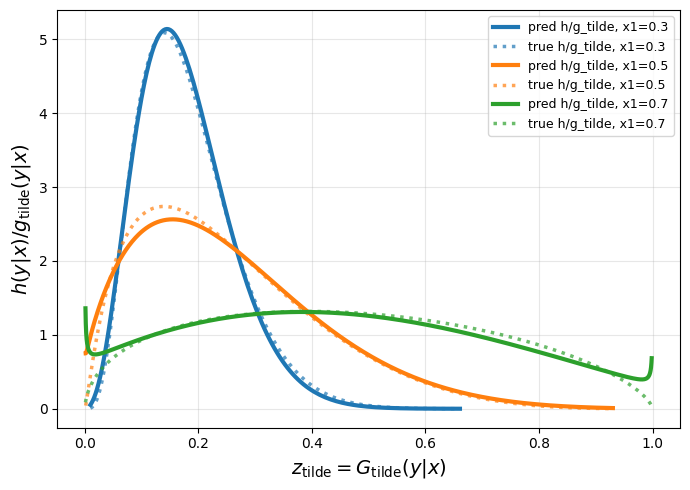

In [18]:
def compute_high_density_z_range(x_star, threshold=0.001):
    y_grid = np.linspace(y_min, y_max, 5000)
    h_true = true_h_np(y_grid, x_star)
    mask = h_true > threshold
    if not np.any(mask):
        return 1e-3, 1 - 1e-3
    y_lo, y_hi = y_grid[mask][0], y_grid[mask][-1]
    mu_base = b_base * base_index(np.asarray(x_star))
    z_lo = norm.cdf(y_lo, loc=mu_base, scale=ORIGINAL_SIGMA_NORMAL)
    z_hi = norm.cdf(y_hi, loc=mu_base, scale=ORIGINAL_SIGMA_NORMAL)
    return max(z_lo, 1e-3), min(z_hi, 1 - 1e-3)

fig_b, ax_b = plt.subplots(1, 1, figsize=(7, 5))
for x_star, col in zip(x_vals, colors):
    yg, _, hhat, _, _ = model.predict_density(x_star, y_min=y_min, y_max=y_max, M=M)
    h_true = true_h_np(yg, x_star)
    g_tilde = g_tilde_np(yg, x_star)
    mu_tilde = b_base * base_index(np.asarray(x_star))
    z_tilde = norm.cdf(yg, loc=mu_tilde, scale=ORIGINAL_SIGMA_NORMAL)
    z_min_dense, z_max_dense = compute_high_density_z_range(x_star)
    mask = (z_tilde > z_min_dense) & (z_tilde < z_max_dense) & (g_tilde > 1e-12)
    order = np.argsort(z_tilde[mask])
    z_plot = z_tilde[mask][order]
    pred_ratio = (hhat[mask] / g_tilde[mask])[order]
    true_ratio = (h_true[mask] / g_tilde[mask])[order]
    ax_b.plot(z_plot, pred_ratio, "-", color=col, lw=3, label=f"pred h/g_tilde, x1={x_star[0]:.1f}")
    ax_b.plot(z_plot, true_ratio, ":", color=col, lw=2.5, alpha=0.7, label=f"true h/g_tilde, x1={x_star[0]:.1f}")
ax_b.set_xlabel(r"$z_{\mathrm{tilde}} = G_{\mathrm{tilde}}(y|x)$", fontsize=14)
ax_b.set_ylabel(r"$h(y|x) / g_{\mathrm{tilde}}(y|x)$", fontsize=14)
ax_b.legend(fontsize=9)
ax_b.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Panel C: fitted mean and 95% interval

Panel C is computed from the package model's predicted densities. We integrate `hhat` over a y-grid for each value of `x1`, with `x2` fixed at the training median. The original Normal base interval and the true simulation interval are shown for comparison.

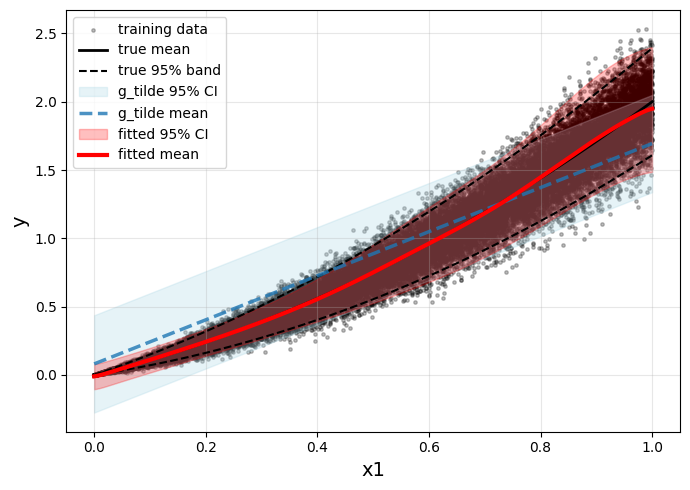

In [19]:
fig_c, ax_c = plt.subplots(1, 1, figsize=(7, 5))
x_line = np.linspace(float(x[:, 0].min()), float(x[:, 0].max()), 250)
x2_fixed = float(x[:, 1].median())

mu_base = b_base * (x_line + 0.1 * x2_fixed)
base_lower = mu_base + ORIGINAL_SIGMA_NORMAL * norm.ppf(0.025)
base_upper = mu_base + ORIGINAL_SIGMA_NORMAL * norm.ppf(0.975)

fitted_mean, fitted_lower, fitted_upper = [], [], []
for x1_star in x_line:
    x_star = np.array([x1_star, x2_fixed])
    yg, _, hhat, _, _ = model.predict_density(x_star, y_min=y_min, y_max=y_max, M=M)
    dy = yg[1] - yg[0]
    h_norm = hhat / (np.trapezoid(hhat, dx=dy) + 1e-12)
    fitted_mean.append(np.trapezoid(yg * h_norm, dx=dy))
    cdf = np.clip(np.cumsum(h_norm) * dy, 0, 1)
    fitted_lower.append(np.interp(0.025, cdf, yg))
    fitted_upper.append(np.interp(0.975, cdf, yg))

fitted_mean = gaussian_filter1d(np.asarray(fitted_mean), sigma=3, mode="nearest")
fitted_lower = gaussian_filter1d(np.asarray(fitted_lower), sigma=3, mode="nearest")
fitted_upper = gaussian_filter1d(np.asarray(fitted_upper), sigma=3, mode="nearest")

ax_c.scatter(x[:, 0].cpu().numpy(), y.cpu().numpy(), s=6, alpha=0.25, color="k", label="training data")
ax_c.plot(x_line, true_mean_np(x_line), color="black", lw=2, label="true mean")
ax_c.plot(x_line, true_mean_np(x_line) + 1.96 * 0.2 * x_line, color="black", linestyle="--", lw=1.5, label="true 95% band")
ax_c.plot(x_line, true_mean_np(x_line) - 1.96 * 0.2 * x_line, color="black", linestyle="--", lw=1.5)
ax_c.fill_between(x_line, base_lower, base_upper, color="lightblue", alpha=0.3, label="g_tilde 95% CI")
ax_c.plot(x_line, mu_base, "--", color="tab:blue", lw=2.5, alpha=0.8, label="g_tilde mean")
ax_c.fill_between(x_line, fitted_lower, fitted_upper, color="red", alpha=0.25, label="fitted 95% CI")
ax_c.plot(x_line, fitted_mean, "-", color="red", lw=3, label="fitted mean")
ax_c.set_xlabel("x1", fontsize=14)
ax_c.set_ylabel("y", fontsize=14)
ax_c.legend(loc="best", fontsize=10)
ax_c.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Test-set diagnostics

These diagnostics also use the original Normal base for the base comparison. The GPDR estimates come from integrating/interpolating the package model's predicted density `hhat`.

In [20]:
true_log_density_vals = 0.0
estimated_log_density_vals = 0.0
base_log_density_vals = 0.0

for i in range(len(x_test)):
    x_star = x_test[i, :].cpu().numpy()
    y_star = float(y_test[i].cpu().numpy().item())
    yg, _, hhat, _, _ = model.predict_density(x_star, y_min=y_min, y_max=y_max, M=1000)
    true_log_density_vals += np.log(max(true_h_np(y_star, x_star), 1e-12))
    estimated_log_density_vals += np.log(max(np.interp(y_star, yg, hhat), 1e-12))
    base_log_density_vals += np.log(max(g_tilde_np(y_star, x_star), 1e-12))

print(f"True Log Density:      {true_log_density_vals:.4f}")
print(f"Estimated Log Density: {estimated_log_density_vals:.4f}")
print(f"Base Log Density:      {base_log_density_vals:.4f}")

True Log Density:      5937.8169
Estimated Log Density: 5081.0301
Base Log Density:      1114.6523


In [21]:
def density_mean_interval(yg, hhat, level=0.95):
    dy = yg[1] - yg[0]
    h_norm = hhat / (np.trapezoid(hhat, dx=dy) + 1e-12)
    mean = np.trapezoid(yg * h_norm, dx=dy)
    cdf = np.clip(np.cumsum(h_norm) * dy, 0, 1)
    lower_q = (1 - level) / 2
    upper_q = 1 - lower_q
    return mean, np.interp(lower_q, cdf, yg), np.interp(upper_q, cdf, yg)

updated_pred, updated_lo, updated_hi = [], [], []
base_pred, base_lo, base_hi = [], [], []
y_obs = []

for i in range(len(x_test)):
    x_star = x_test[i, :].cpu().numpy()
    y_star = float(y_test[i].cpu().numpy().item())
    y_obs.append(y_star)
    yg, _, hhat, _, _ = model.predict_density(x_star, y_min=y_min, y_max=y_max, M=1000)
    mean_u, lo_u, hi_u = density_mean_interval(yg, hhat, level=0.95)
    updated_pred.append(mean_u)
    updated_lo.append(lo_u)
    updated_hi.append(hi_u)
    mu_b = b_base * base_index(x_star)
    base_pred.append(mu_b)
    base_lo.append(mu_b + ORIGINAL_SIGMA_NORMAL * norm.ppf(0.025))
    base_hi.append(mu_b + ORIGINAL_SIGMA_NORMAL * norm.ppf(0.975))

y_obs = np.asarray(y_obs)
updated_pred = np.asarray(updated_pred)
updated_lo = np.asarray(updated_lo)
updated_hi = np.asarray(updated_hi)
base_pred = np.asarray(base_pred)
base_lo = np.asarray(base_lo)
base_hi = np.asarray(base_hi)

print("MODEL COMPARISON DIAGNOSTICS")
print("=" * 60)
print(f"Updated RMSE: {np.sqrt(np.mean((updated_pred - y_obs) ** 2)):.4f} | Base RMSE: {np.sqrt(np.mean((base_pred - y_obs) ** 2)):.4f}")
print(f"Updated 95% coverage: {np.mean((y_obs >= updated_lo) & (y_obs <= updated_hi)):.4f} | Base 95% coverage: {np.mean((y_obs >= base_lo) & (y_obs <= base_hi)):.4f}")
print(f"Updated 95% avg width: {np.mean(updated_hi - updated_lo):.4f} | Base 95% avg width: {np.mean(base_hi - base_lo):.4f}")

MODEL COMPARISON DIAGNOSTICS
Updated RMSE: 0.1157 | Base RMSE: 0.1929
Updated 95% coverage: 0.9768 | Base 95% coverage: 0.9508
Updated 95% avg width: 0.4766 | Base 95% avg width: 0.7122


## 9. How to adapt this template

For a new dataset, keep the same package workflow and replace only the problem-specific pieces:

- Replace `prepare_multix_toy_data` with your own data preparation returning tensors `x`, `y`, `x_test`, and `y_test`.
- Choose an original base model for scientific comparison, such as a Normal GLM/GAM, and write its PDF/CDF helper for figures.
- Choose the training base passed to GPDR. For heavy-tail robustness, use the same location as the original base but a diffuse Student-t scale.
- Select `KernelParams(log_sigma2, log_lx2, log_lz2)` and `beta`. In this example beta is the most influential knob for matching the mean/CI behavior in Panel C.
- Use `LogisticGPMixtureDiag` or an example-specific builder, train with `fit_adam`, then draw figures from `model.predict_density`.

The key rule from this example is: training may use a heavy-tail base, but figures and reported base metrics should use the original base model you want GPDR to improve over.